In [1]:
# Load Data
import numpy as np

container = np.load('split_data.npz')

# Access data
X_train = container['X_train']
y_train = container['y_train']

# Access data
X_test = container['X_test']
y_test = container['y_test']

In [2]:
from kernel_models import NadarayaWatson, SmoothKernels
from sklearn.metrics import r2_score

h_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 1e+1, 1e+2, 1e+3]
# h_list = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1] # Should have considered

result_list = []

for h in h_list:
    # Cosine kernel
    model = NadarayaWatson(h=h, kernel=SmoothKernels.cosine)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_train)
    
    score = r2_score(y_train, y_pred)

    params = {'h': h, 'kernel': 'Cosine'} 
    result = {'score': score, 'params': params}
    result_list.append(result)
    
    # Epanechnikov kernel
    model = NadarayaWatson(h=h, kernel=SmoothKernels.epanechnikov)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_train)
    
    score = r2_score(y_train, y_pred)

    params = {'h': h, 'kernel': 'Epanechnikov'} 
    result = {'score': score, 'params': params}
    result_list.append(result)

    # Exponential kernel
    model = NadarayaWatson(h=h, kernel=SmoothKernels.exponential)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_train)
    
    score = r2_score(y_train, y_pred)

    params = {'h': h, 'kernel': 'Exponential'} 
    result = {'score': score, 'params': params}
    result_list.append(result)

    # Gaussian kernel
    model = NadarayaWatson(h=h, kernel=SmoothKernels.gaussian)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_train)
    
    score = r2_score(y_train, y_pred)

    params = {'h': h, 'kernel': 'Gaussian'} 
    result = {'score': score, 'params': params}
    result_list.append(result)

    # Triangular kernel
    model = NadarayaWatson(h=h, kernel=SmoothKernels.triangular)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_train)
    
    score = r2_score(y_train, y_pred)

    params = {'h': h, 'kernel': 'Triangular'} 
    result = {'score': score, 'params': params}
    result_list.append(result)

    # Uniform kernel
    model = NadarayaWatson(h=h, kernel=SmoothKernels.uniform)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_train)
    
    score = r2_score(y_train, y_pred)

    params = {'h': h, 'kernel': 'Uniform'} 
    result = {'score': score, 'params': params}
    result_list.append(result)

best_result = max(result_list, key=lambda x: x['score'])

print(f"Max Score: {best_result['score']}")
print(f"Best Params: {best_result['params']}")

Max Score: 0.8070454458986446
Best Params: {'h': 1, 'kernel': 'Triangular'}


In [4]:
from kernel_models import NadarayaWatson, SmoothKernels
from sklearn.metrics import r2_score

model = NadarayaWatson(h=1, kernel=SmoothKernels.triangular)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(r2_score(y_test, y_pred))

0.8140531379411727


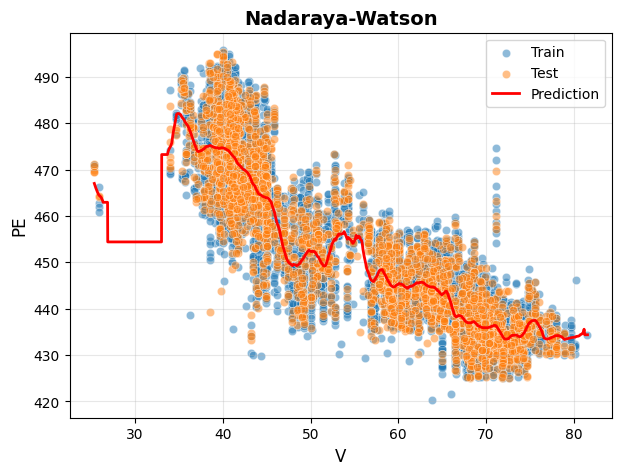

In [5]:
from utils import plot_predictions

step = 0.01
X_min = min(X_train.min(), X_test.min())
X_max = max(X_train.max(), X_test.max())
X_line = np.arange(X_min, X_max + step, step).reshape(-1, 1)
y_line = model.predict(X_line)

plot_predictions(X_line, y_line, X_train, y_train, X_test, y_test, title='Nadaraya-Watson', name='Images/nadaraya_watson.png')